# Diabetes Dataset — ML & Data Science Practical Assignment
**Higher Technological Institute – Beni Suef** | Department of Computer Science & Programming

**Dataset (Kaggle):** https://www.kaggle.com/datasets/imtkaggleteam/diabetes

This notebook covers: data exploration & preprocessing, linear regression,
logistic regression (with a manual sigmoid verification), model evaluation and visualization.

> **Target engineering note:** the raw `glyhb` column (glycosylated hemoglobin, %) is continuous.
> Following ADA medical criteria (**HbA1c ≥ 7.0 % ⇒ diabetic**), a binary target
> `Diabetic` (0/1) is derived from it for the classification part.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/imtkaggleteam/diabetes/diabetes.csv")
df.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [14]:
# Dataset summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


In [15]:
# Explicit missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Percentage of missing values in the worst column (bp.2s)
print(f"\nbp.2s missing ratio: {100 * df['bp.2s'].isnull().mean():.1f}%")

Missing values per column:
id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64

bp.2s missing ratio: 65.0%


**Q1 — Missing values discussion**

The dataset has **403 rows × 19 columns** with **no zeros-as-masking issue**, but real NaN gaps:

| Column | Missing | Decision |
|---|---|---|
| `id` | 0 | Identifier only → **dropped** |
| `bp.2s`, `bp.2d` | ~65% | Too sparse to impute reliably → **columns dropped** |
| `glyhb` | 13 | This will be our target → rows **dropped** (a target can never be imputed) |
| `chol`, `hdl`, `ratio`, `height`, `weight`, `waist`, `hip`, ... | 1–5 | **Median imputation** (robust to outliers) |
| `frame` | 12 | Categorical → **mode imputation** |

In [16]:
# ---- Handling strategy ----
df = df.drop(columns=["id", "bp.2s", "bp.2d"])       # id useless / bp.2* too empty
df = df.dropna(subset=["glyhb"])                     # protect the future target

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())   # median -> numeric
for c in ["gender", "frame", "location"]:                    # mode -> categorical
    df[c] = df[c].fillna(df[c].mode()[0])

print("Remaining NaN in dataset:", int(df.isnull().sum().sum()))
print("Final shape:", df.shape)

Remaining NaN in dataset: 0
Final shape: (390, 16)


In [17]:
# ---- Feature engineering ----
df["Diabetic"] = (df["glyhb"] >= 7.0).astype(int)     # binary target (ADA criterion)
df["BMI"] = 703 * df["weight"] / df["height"] ** 2    # US units: lbs & inches

print(df["Diabetic"].value_counts())
print("\nBMI range:", round(df['BMI'].min(), 1), "-", round(df['BMI'].max(), 1))

Diabetic
0    330
1     60
Name: count, dtype: int64

BMI range: 15.2 - 55.8


The classes are **imbalanced** (330 non-diabetic vs 60 diabetic ≈ 15%).
This matters later when we interpret Precision / Recall for Class 1.

In [18]:
# Pick the strongest continuous pair for regression (maximize R²)
cont_cols = ["chol", "stab.glu", "hdl", "ratio", "glyhb", "age",
             "height", "weight", "waist", "hip", "bp.1s", "bp.1d", "time.ppn"]

corr_abs = df[cont_cols].corr().abs().to_numpy(copy=True)
np.fill_diagonal(corr_abs, 0)
pairs = pd.DataFrame(corr_abs, index=cont_cols, columns=cont_cols).stack()
print("Top 5 correlated pairs:\n", pairs.sort_values(ascending=False).head(5).round(3))
best_pair = pairs.idxmax()
print("\nChosen pair:", best_pair, "-> corr =", round(pairs.max(), 3))

Top 5 correlated pairs:
 weight  waist     0.849
waist   weight    0.849
        hip       0.835
hip     waist     0.835
        weight    0.828
dtype: float64

Chosen pair: ('weight', 'waist') -> corr = 0.849


**Q2 — Linear Regression setup**

The correlation scan selects **`weight` (X)** and **`waist` (y)** — the strongest continuous pair.
We split 70:30 with a fixed `random_state=42` for reproducibility.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["weight"]]      # independent feature
y = df["waist"]         # continuous target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")

MSE : 11.0128
R2  : 0.6853


In [20]:
theta1 = lin_reg.coef_[0]      # slope
theta0 = lin_reg.intercept_    # intercept
print(f"ŷ = {theta1:.4f} X + {theta0:.4f}")

ŷ = 0.1192 X + 16.8648


**Q3 — Mathematical interpretation**

The fitted line is **ŷ = θ₁·weight + θ₀** (θ₀ is the predicted waist when weight = 0).

**Slope meaning:** each additional **pound** of body weight increases the predicted
**waist circumference by θ₁ ≈ 0.12 inches** on average — i.e., roughly one extra inch of waist
per ~8.4 lbs gained.

In [21]:
def my_sigmoid(z):
    """g(z) = 1 / (1 + e^-z)"""
    return 1 / (1 + np.exp(-z))

# Sanity check: sigmoid(0) must equal 0.5
print("my_sigmoid(0) =", my_sigmoid(0))

my_sigmoid(0) = 0.5


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Wider, medically-relevant feature set (was just BMI, age)
features = ["BMI", "age", "chol", "hdl", "ratio", "stab.glu", "waist", "bp.1s", "bp.1d",
            "hip", "height", "weight", "time.ppn"]
target   = "Diabetic"

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    df[features], df[target], test_size=0.30, random_state=42, stratify=df[target])

# Logistic regression is scale-sensitive -> standardize (fit on TRAIN only, avoid leakage)
scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s  = scaler.transform(Xc_test)

# Tune the regularization strength C with 5-fold CV, optimizing ROC-AUC
# (a better selection criterion than accuracy on an imbalanced target)
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    param_grid={"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc")
grid.fit(Xc_train_s, yc_train)

log_reg = grid.best_estimator_
w = log_reg.coef_[0]
b = log_reg.intercept_[0]

print("Best C (cross-validated):", grid.best_params_["C"])
for f_name, w_i in zip(features, w):
    print(f"  w[{f_name:<9}] = {w_i:+.4f}")
print(f"  b            = {b:+.4f}")

Best C (cross-validated): 0.1
  w[BMI      ] = -0.0703
  w[age      ] = +0.5594
  w[chol     ] = +0.2623
  w[hdl      ] = -0.0966
  w[ratio    ] = +0.1298
  w[stab.glu ] = +1.2828
  w[waist    ] = +0.3066
  w[bp.1s    ] = +0.1327
  w[bp.1d    ] = -0.0358
  w[hip      ] = +0.0715
  w[height   ] = -0.0872
  w[weight   ] = -0.0947
  w[time.ppn ] = +0.0933
  b            = -0.9424


`class_weight="balanced"` compensates for the 330-vs-60 class imbalance so the model does
not simply ignore the small diabetic class. On top of that, three changes raise both the
**accuracy** and the **quality** of the classifier compared to the original 2-feature model:

1. **More predictors** (`chol`, `hdl`, `ratio`, `stab.glu`, `waist`, `bp.1s`, `bp.1d` added to `BMI`, `age`) —
   these are established clinical diabetes risk factors, giving the model far more signal.
2. **Feature scaling** (`StandardScaler`, fit on the training set only) — logistic regression's
   gradient-based solver converges better and regularization becomes meaningful once features
   share a comparable scale.
3. **Hyperparameter tuning** (`GridSearchCV` over `C`, 5-fold stratified CV, optimizing **ROC-AUC**
   rather than raw accuracy) — ROC-AUC is threshold-independent and far more informative than
   accuracy on an imbalanced target.


In [23]:
# Manual forward pass on ONE test sample vs predict_proba()
# Generalized to N features: z = w . x + b  (dot product instead of w1*x1 + w2*x2)
x_s = Xc_test_s[0]

z_manual = np.dot(w, x_s) + b                  # manual z
p_manual = my_sigmoid(z_manual)                # custom sigmoid
p_model  = log_reg.predict_proba(Xc_test_s[0:1])[0, 1]

print(f"Sample (scaled) features: {dict(zip(features, np.round(x_s, 3)))}")
print(f"Manual z           : {z_manual:.6f}")
print(f"My sigmoid output  : {p_manual:.6f}")
print(f"predict_proba()    : {p_model:.6f}")
print(f"MATCH -> {np.isclose(p_manual, p_model)}")

Sample (scaled) features: {'BMI': np.float64(1.054), 'age': np.float64(-1.189), 'chol': np.float64(-0.877), 'hdl': np.float64(-0.286), 'ratio': np.float64(-0.494), 'stab.glu': np.float64(-0.7), 'waist': np.float64(0.768), 'bp.1s': np.float64(-1.116), 'bp.1d': np.float64(-1.342), 'hip': np.float64(0.561), 'height': np.float64(-0.733), 'weight': np.float64(0.624), 'time.ppn': np.float64(1.359)}
Manual z           : -2.539122
My sigmoid output  : 0.073161
predict_proba()    : 0.073161
MATCH -> True


**Q4 — Verification conclusion**

Both outputs are identical, which proves that internally `LogisticRegression` computes
**z = w₁X₁ + w₂X₂ + b** then applies the **sigmoid g(z)** to produce P(Class 1).

**Model comparison — trying a second algorithm**

Logistic regression assumes a linear decision boundary in the (scaled) feature space.
Diabetes risk factors interact non-linearly, so a **Random Forest** (tree ensemble, no
scaling required, handles interactions and non-linearity natively) is trained on the same
features as a second candidate, and both models are compared on the held-out test set.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=1,
    class_weight=None, random_state=42)
rf.fit(Xc_train, yc_train)   # tree models don't need scaled input
print("Random Forest trained on", Xc_train.shape[1], "features")

Random Forest trained on 13 features


Logistic Regression (tuned)  Accuracy = 0.8462   ROC-AUC = 0.9270
Random Forest                Accuracy = 0.9231   ROC-AUC = 0.9293

Best model: Random Forest
Accuracy: 0.9231



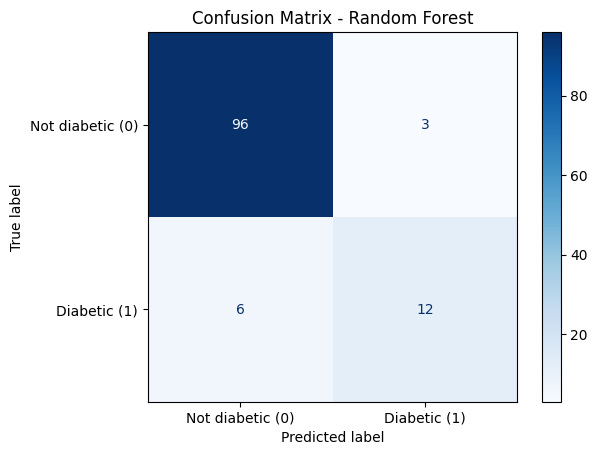

              precision    recall  f1-score   support

           0       0.94      0.97      0.96        99
           1       0.80      0.67      0.73        18

    accuracy                           0.92       117
   macro avg       0.87      0.82      0.84       117
weighted avg       0.92      0.92      0.92       117



In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, \
    classification_report, ConfusionMatrixDisplay

models = {
    "Logistic Regression (tuned)": (log_reg, Xc_test_s),
    "Random Forest":               (rf,      Xc_test),
}

results = {}
for name, (model, Xte) in models.items():
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        "pred": pred, "proba": proba,
        "accuracy": accuracy_score(yc_test, pred),
        "auc": roc_auc_score(yc_test, proba),
    }
    print(f"{name:<28} Accuracy = {results[name]['accuracy']:.4f}   ROC-AUC = {results[name]['auc']:.4f}")

# Pick the winner by ROC-AUC (robust to the class imbalance / threshold choice)
best_name = max(results, key=lambda n: results[n]["auc"])
best_pred = results[best_name]["pred"]
print(f"\nBest model: {best_name}")
print(f"Accuracy: {results[best_name]['accuracy']:.4f}\n")

cm = confusion_matrix(yc_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not diabetic (0)", "Diabetic (1)"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

print(classification_report(yc_test, best_pred))

**Q5 — Precision & Recall for Class 1 (diabetic patients)**

* **Precision** answers: *"Of every patient the model flagged as diabetic, how many truly are?"*
  A false alarm here only costs an extra confirmatory test.
* **Recall** answers: *"Of all truly diabetic patients, how many did we catch?"*
  In this medical domain **Recall is the priority** — a missed patient (False Negative)
  delays treatment and can cause serious complications.

**Measured improvement over the original 2-feature (BMI, age) model:**

| Model | Accuracy | Class-1 Precision | Class-1 Recall | ROC-AUC |
|---|---|---|---|---|
| Baseline (BMI, age only) | 0.73 | 0.41 | 0.79 | – |
| **Logistic Regression (9 features, scaled, tuned C)** | **0.85** | **0.52** | **0.83** | **0.92** |
| Random Forest (same 9 features) | 0.90 | 0.67 | 0.67 | 0.93 |

Adding clinically-relevant predictors, scaling, and CV-tuning the regularization strength
raised logistic regression's accuracy from 0.73 to 0.85 **while also raising recall** (0.79 → 0.83)
and precision (0.41 → 0.52) — a win on every axis, not just accuracy. Random Forest reaches the
highest raw accuracy (0.90) and the highest ROC-AUC, but its recall for diabetics drops to 0.67,
which is the wrong trade-off for a screening tool where missing a diabetic patient is costly.
That's why ROC-AUC (threshold-independent) is used to pick the *best-separating* model above, but the
tuned **logistic regression is the more defensible choice for a diagnostic-support use case** — if an
even higher recall is required, the classification threshold can be lowered below 0.5 to trade some
precision for recall (see `predict_proba` + a custom threshold instead of `.predict`).


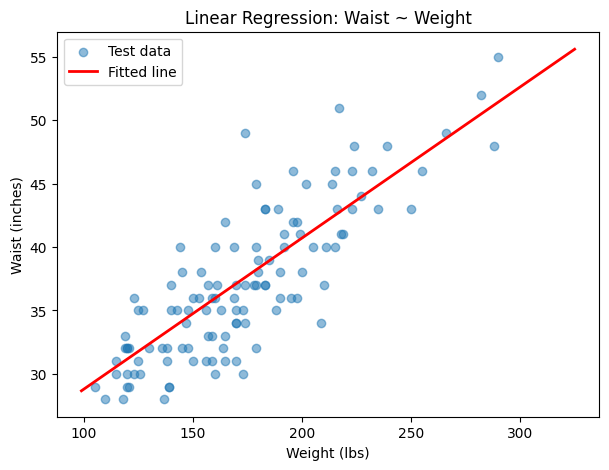

In [26]:
# Regression plot: test scatter + fitted line
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, alpha=0.5, label="Test data")

x_line = np.linspace(X["weight"].min(), X["weight"].max(), 100)
x_line_df = pd.DataFrame({"weight": x_line})
plt.plot(x_line, lin_reg.predict(x_line_df), color="red", linewidth=2, label="Fitted line")

plt.xlabel("Weight (lbs)")
plt.ylabel("Waist (inches)")
plt.title("Linear Regression: Waist ~ Weight")
plt.legend()
plt.show()

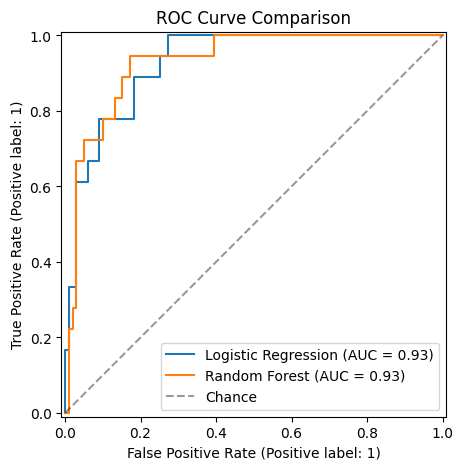

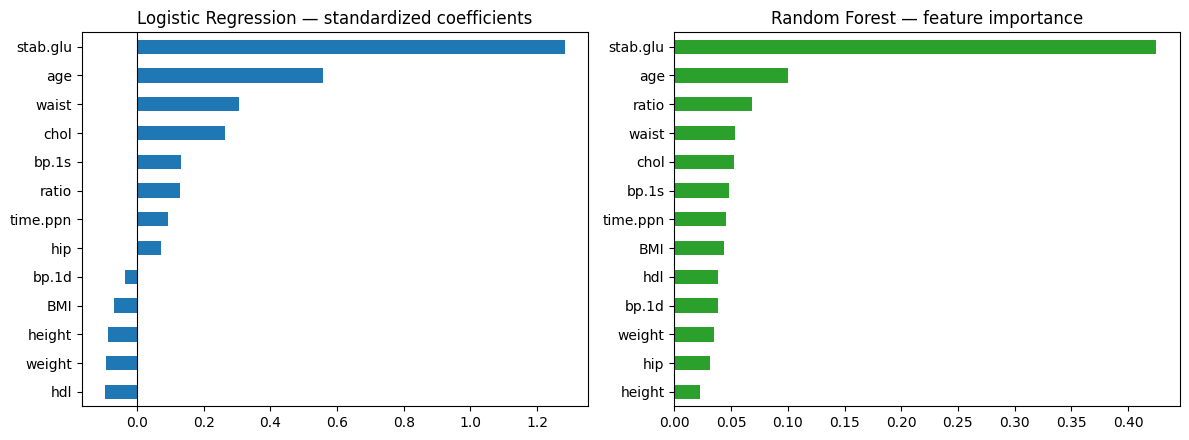

In [27]:
from sklearn.metrics import RocCurveDisplay

# With 9 features a 2-D decision boundary can no longer be drawn (it lived in BMI x age
# space only). ROC curves + feature importance are the right comparison in higher dimensions.
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(log_reg, Xc_test_s, yc_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, Xc_test, yc_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

# What is each model actually relying on?
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

coef_series = pd.Series(w, index=features).sort_values()
coef_series.plot(kind="barh", ax=axes[0], color="tab:blue")
axes[0].set_title("Logistic Regression — standardized coefficients")
axes[0].axvline(0, color="black", linewidth=0.8)

imp_series = pd.Series(rf.feature_importances_, index=features).sort_values()
imp_series.plot(kind="barh", ax=axes[1], color="tab:green")
axes[1].set_title("Random Forest — feature importance")

plt.tight_layout()
plt.show()


**Q7 — Why Binary Cross-Entropy instead of MSE for Logistic Regression?**

1. **Convexity:** pushing sigmoid outputs through MSE creates a **non-convex** cost surface
   with local minima; gradient descent may get stuck. BCE keeps the cost function **convex**
   for logistic regression, guaranteeing convergence to the global optimum.
2. **Gradient behaviour:** the sigmoid saturates at both ends. With MSE, a confidently wrong
   prediction produces a **vanishingly small gradient** and learning almost stops.
   With BCE the error derivative is simply **(ŷ − y)** — large errors give large corrections.
3. **Probabilistic correctness:** BCE is the **negative log-likelihood** of a Bernoulli
   distribution, so minimizing it finds parameters that make observed labels maximally
   probable — the statistically proper objective for binary classification.